In [2]:
import pandas as pd
import numpy as np
import re, ast, os
from itertools import groupby
from scipy.stats import bootstrap
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score

In [3]:
from irrCAC.raw import CAC


In [82]:
instruction = pd.read_csv('../../question_info/question_info_updated.csv', header=0)
# instruction = instruction.fillna('None')
instruction['choices_text'] = instruction['choices_text'].apply(ast.literal_eval)
instruction['choices_index'] = instruction['choices_index'].apply(ast.literal_eval)
instruction['addition_context'] = instruction['addition_context'].apply(ast.literal_eval)

In [69]:
folder_names =  ['spirit_consort-identified/gpt-5-chat-latest_spirit_consort/', 'Qwen/Qwen2.5-72B-Instruct-spirit_consort/', 'baseline/', 
                 'exper-annotated/gpt-5-chat-latest_human/', 'spirit_consort-identified/gpt-5-chat-latest-nocot/', 
                 'spirit_consort-identified/gpt-5-chat-latestspirit_consort_LLM_instruction/', 
                 'spirit_consort-identified/gpt-5-chat-latest_random_example/', 
                'spirit_consort-identified/gpt-5-chat-latest_similar_example_spirit_consort_pubmed/',
                'spirit_consort-identified/gpt-5-chat-latest_similar_example_spirit_consort_qwen/', 
                 'exper-annotated/gpt-5-chat-latest_random_example/',
                 'exper-annotated/gpt-5-chat-latest_similar_example_pubmed/',
                'exper-annotated/gpt-5-chat-latest_similar_example_qwen/',
                '10articles/gpt-5-chat-latest-extract-chunk-then-verify', 
                 '10articles/gpt-5-chat-latest-direct-fulltext']

folder_name = folder_names[3]
# folder_name = '../annotations/'

In [70]:
# F1 evaluation

In [71]:
def calculate_report(item, file, column):
    n_options = file[[i for i in file.columns if item in i]].shape[1]
    truth = file[[i for i in file.columns if item in i]].values.tolist()
    if n_options != 1:
        dummy = []
        for j in file[column]:
            if j:
                original = [0] * n_options
                for i in j:
                    original[i-1] = 1
                dummy.append(original)
            else:
                dummy.append([0] * n_options)
        return precision_score(truth, dummy, average='micro'), recall_score(truth, dummy, average='micro'), f1_score(truth, dummy, average='micro')
    else:
        predict = [j[0] for j in file[column]]
        return precision_score(truth, predict, average='micro'), recall_score(truth, predict, average='micro'), f1_score(truth, predict,average='micro')

In [72]:
precision, recall, f1 = dict(), dict(), dict()
column_name = 'formatted_output'
# column_name = 'andrew'
select_items = ['b27c', 'r50b', 'b45a','r12f', 'r2a', 'p23a', 'b15f', 'r16c', 'p40b', 'b2a']
for j, row in instruction[['question_index', 'type', 'applicability', 'context', 'choices_index']].iterrows():
    # if row.question_index in select_items:
    file_item = pd.read_csv(os.path.join(folder_name, row['question_index']+'.csv'), header=0)
    if row['applicability'] == 'Protocol':
        file_item = file_item[file_item.report_type==1]
    elif row['applicability'] == 'Results':
        file_item = file_item[file_item.report_type==2]
    file_item = file_item.reset_index(drop=True)
    
    # file_item = file_item[file_item[row.context].notna()]
    # file_item = file_item[file_item[column_name].notna()]

    # for choice in row['choices_index']:
    #     file_item = file_item[file_item[choice].notna()]

    if column_name in file_item.columns:
        text_col = instruction[instruction.question_index == row['question_index']].context.values[0]
        option_col = instruction[instruction.question_index == row['question_index']].choices_index.tolist()[0]
        # file_item['formatted_output'] = file_item['formatted_output'].replace(choice)
        # file_item = file_item[~(file_item[text_col].isna()|file_item[option_col[0]].isna())]
        if row.type == 'choice':
            if 'b5a' in row.question_index:
                truth = file_item[option_col].apply(lambda x: x.tolist().index(1)+1, axis=1)
                p = precision_score(truth, file_item[column_name], average='micro')
                r = recall_score(truth, file_item[column_name], average='micro')
                f = f1_score(truth, file_item[column_name], average='micro')
            else:
                p = precision_score(file_item[row.question_index], file_item[column_name], average='micro')
                r = recall_score(file_item[row.question_index], file_item[column_name], average='micro')
                f = f1_score(file_item[row.question_index], file_item[column_name], average='micro')

        else:
            file_item[column_name] = file_item[column_name].apply(ast.literal_eval)
            p, r, f = calculate_report(row['question_index'], file_item, column_name)
        precision[row.question_index] = p
        recall[row.question_index] = r
        f1[row.question_index] = f
b2b_f, b5a_f, other_f = [], [], dict()
for i in precision:
    if 'b2b' in i:
        b2b_f.append(f1[i])
    elif 'b5a' in i:
        b5a_f.append(f1[i])
    else:
        other_f[i] = f1[i]
other_f['b2b'] = sum(b2b_f)/len(b2b_f)
other_f['b5a'] = sum(b5a_f)/len(b5a_f)

In [73]:
consort = instruction[(instruction['SPIRIT'].isna()&instruction['CONSORT'].notna())].question_index.tolist()

spirit = instruction[(instruction['SPIRIT'].notna()&instruction['CONSORT'].isna())].question_index.tolist()

both = instruction[(instruction['SPIRIT'].notna()&instruction['CONSORT'].notna())].question_index.tolist()
both.remove('b2b__study_design')
both.remove('b2b__data_collection_management')
both.remove('b2b__writing_of_the_report')
both.remove('b2b__decision_to_submit_the_rep')
spirit.remove('b5a__coordinating_center')
spirit.remove('b5a__steering_committee')
spirit.remove('b5a__endpoint_adjudication_comm')
spirit.remove('b5a__data_management_team')
both.append('b2b')
spirit.append('b5a')

In [74]:
check_one = instruction[instruction['type']=='choice'].question_index.tolist()
check_one.remove('b2b__study_design')
check_one.remove('b2b__data_collection_management')
check_one.remove('b2b__writing_of_the_report')
check_one.remove('b2b__decision_to_submit_the_rep')
check_one.append('b2b')
check_all_apply = instruction[instruction['type']=='multilabel'].question_index.tolist()
check_all_apply.remove('b5a__coordinating_center')
check_all_apply.remove('b5a__steering_committee')
check_all_apply.remove('b5a__endpoint_adjudication_comm')
check_all_apply.remove('b5a__data_management_team')
check_all_apply.append('b5a')

In [75]:
# data = (list(other_f.values()),)
# bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
#                          random_state=1, method='percentile')
# all_f1.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

# data = ([other_f[key] for key in other_f if key in consort],)
# bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
#                          random_state=1, method='percentile')
# consort_f1.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

# data = ([other_f[key] for key in other_f if key in spirit],)
# bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
#                          random_state=1, method='percentile')
# spirit_f1.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

# data = ([other_f[key] for key in other_f if key in both],)
# bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
#                          random_state=1, method='percentile')
# both_f1.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

# data = ([other_f[key] for key in other_f if key in check_one],)
# bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
#                          random_state=1, method='percentile')
# check_one_f1.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

# data = ([other_f[key] for key in other_f if key in check_all_apply],)
# bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
#                          random_state=1, method='percentile')
# check_all_apply_f1.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

In [76]:
from nltk import agreement
from nltk.metrics.distance import masi_distance
from nltk.metrics.agreement import AnnotationTask

In [77]:
import numpy as np
column_name = 'formatted_output'
# column_name = 'andrew'
from collections import defaultdict

gwet = defaultdict(list)
krip = defaultdict(list)
acc_scores = defaultdict(list)

select_items = ['b27c', 'r50b', 'b45a','r12f', 'r2a', 'p23a', 'b15f', 'r16c', 'p40b', 'b2a']
for j, row in instruction[['question_index', 'type', 'applicability', 'context', 'choices_index']].iterrows():
    # if row.question_index in select_items:
    file_item = pd.read_csv(os.path.join(folder_name, row['question_index']+'.csv'), header=0)
    if row['applicability'] == 'Protocol':
        file_item = file_item[file_item.report_type==1]
    elif row['applicability'] == 'Results':
        file_item = file_item[file_item.report_type==2]
    file_item = file_item.reset_index(drop=True)
    
    # file_item = file_item[file_item[row.context].notna()]
    # file_item = file_item[file_item[column_name].notna()]
    # file_item = file_item.reset_index(drop=True)

    if file_item.shape[0] == 1 or file_item.shape[0] == 0:
        continue

    # for choice in row['choices_index']:
    #     file_item = file_item[file_item[choice].notna()]
    
    if column_name in file_item.columns:
        text_col = instruction[instruction.question_index == row['question_index']].context.values[0]
        option_col = instruction[instruction.question_index == row['question_index']].choices_index.tolist()[0]
        # file_item['formatted_output'] = file_item['formatted_output'].replace(choice)
        # file_item = file_item[~(file_item[text_col].isna()|file_item[option_col[0]].isna())]
        if row.type == 'choice':
            task_data = []
            # if 'b5a' in row.question_index:
            #     truth = file_item[option_col].apply(lambda x: x.tolist().index(1)+1, axis=1)
            #     data = pd.DataFrame()
            #     data['truth'] = truth
            #     data['predict'] = file_item[column_name]
            #     cac_4raters = CAC(data)
            #     gwet[row.question_index].append(cac_4raters.gwet()['est']['coefficient_value'])
                
            #     for index, ann in enumerate(zip(truth, file_item[column_name])):
            #         task_data.append((0, str(index), frozenset([str(ann[0])])))
            #         task_data.append((1, str(index), frozenset([str(ann[1])])))
            #     masi_task = AnnotationTask(data=task_data,distance = masi_distance)
            #     krip[row.question_index].append(masi_task.alpha())

            #     acc_scores[row['question_index'].split('__')[0]].append(accuracy_score(truth, file_item[column_name]))
                
            #     # if not cohen_kappa_score(truth, file_item[column_name])!=cohen_kappa_score(truth, file_item[column_name]):
            #     #     kappa_scores[row.question_index]=cohen_kappa_score(truth, file_item[column_name])
            # else:
            data = pd.DataFrame()
            data['truth'] = file_item[row.question_index]
            data['predict'] = file_item[column_name]
            cac_4raters = CAC(data)
            gwet[row['question_index'].split('__')[0]].append(cac_4raters.gwet()['est']['coefficient_value'])

            for index, ann in enumerate(zip(file_item[row.question_index], file_item[column_name])):
                task_data.append((0, str(index), frozenset([str(int(ann[0]))])))
                task_data.append((1, str(index), frozenset([str(int(ann[1]))])))
            masi_task = AnnotationTask(data=task_data,distance = masi_distance)
            # krip[row['question_index'].split('__')[0]].append(masi_task.alpha())

            acc_scores[row['question_index'].split('__')[0]].append(accuracy_score(file_item[row.question_index], file_item[column_name]))
                # if not cohen_kappa_score(file_item[row.question_index], file_item[column_name])!=cohen_kappa_score(file_item[row.question_index], file_item[column_name]):
                #     kappa_scores[row.question_index]=cohen_kappa_score(file_item[row.question_index], file_item[column_name])


        else:
            task_data = []
            file_item[column_name] = file_item[column_name].apply(ast.literal_eval)
            
            n_options = file_item[[i for i in file_item.columns if row['question_index'] in i]].shape[1]
            truth = file_item[[i for i in file_item.columns if row['question_index'] in i]].values
            truth_num = []
            if n_options != 1:
                truth_num = [[i+1 for i, v in enumerate(l) if v == 1] for l in truth]
                # if len(predict) == 0:
                #     kappa_scores[row.question_index]=0
                # else:
                
                # for index, ann in enumerate(zip(truth_num, file_item[column_name])):
                #     if len(ann[0])!=0:
                #         task_data.append((0, str(index), frozenset(ann[0])))
                #     if len(ann[1])!=0:
                #         task_data.append((1, str(index), frozenset(ann[1])))
                # masi_task = AnnotationTask(data=task_data,distance = masi_distance)
                # krip[row['question_index'].split('__')[0]].append(masi_task.alpha())
                
                prediction = np.zeros(truth.shape)
                for index, annotation in file_item[column_name].items():
                    for index_option in annotation:
                        prediction[index, index_option-1]=1
                predict = []
                for i in range(truth.shape[1]):
                    data = pd.DataFrame()
                    data['xiangji'] = truth[:, i]
                    data['andrew'] = prediction[:, i]
                    acc_scores[row['question_index'].split('__')[0]].append(accuracy_score(truth[:, i], prediction[:, i]))
                    
                    cac_4raters = CAC(data)
                    gwet[row['question_index'].split('__')[0]].append(cac_4raters.gwet()['est']['coefficient_value'])
                #     if not cohen_kappa_score(truth[:, i], prediction[:, i])!=cohen_kappa_score(truth[:, i], prediction[:, i]):
                #         predict.append(cohen_kappa_score(truth[:, i], prediction[:, i]))
                # if len(predict) == 0:
                #     kappa_scores[row['question_index']]=0
                # else:
                #     kappa_scores[row['question_index']]=sum(predict)/len(predict)
                # print(pd.DataFrame([truth_num, predict], columns=['c1', 'c2']))
            else:
                predict = [j[0] for j in file[column_name]]
                print(predict)
                print(o)
# b2b_kappa, b5a_kappa, other_kappa = [], [], dict()
# for i in kappa_scores:
#     if 'b2b' in i:
#         b2b_kappa.append(kappa_scores[i])
#     elif 'b5a' in i:
#         b5a_kappa.append(kappa_scores[i])
#     else:
#         other_kappa[i] = kappa_scores[i]
# other_kappa['b2b'] = sum(b2b_kappa)/len(b2b_kappa)
# other_kappa['b5a'] = sum(b5a_kappa)/len(b5a_kappa)

/opt/homebrew/anaconda3/envs/textmining/lib/python3.12/site-packages/irrCAC/raw.py:263: RuntimeWarning: divide by zero encountered in scalar divide
  (weights_mat_sum / (self.q * (self.q - 1)))
/opt/homebrew/anaconda3/envs/textmining/lib/python3.12/site-packages/irrCAC/raw.py:263: RuntimeWarning: invalid value encountered in multiply
  (weights_mat_sum / (self.q * (self.q - 1)))
/opt/homebrew/anaconda3/envs/textmining/lib/python3.12/site-packages/irrCAC/raw.py:263: RuntimeWarning: divide by zero encountered in scalar divide
  (weights_mat_sum / (self.q * (self.q - 1)))
/opt/homebrew/anaconda3/envs/textmining/lib/python3.12/site-packages/irrCAC/raw.py:263: RuntimeWarning: invalid value encountered in multiply
  (weights_mat_sum / (self.q * (self.q - 1)))
/opt/homebrew/anaconda3/envs/textmining/lib/python3.12/site-packages/irrCAC/raw.py:263: RuntimeWarning: divide by zero encountered in scalar divide
  (weights_mat_sum / (self.q * (self.q - 1)))
/opt/homebrew/anaconda3/envs/textmining/li

In [78]:
acc = {k:sum(acc_scores[k])/len(acc_scores[k]) for k in acc_scores}
gwet = {k:sum(gwet[k])/len(gwet[k]) for k in gwet}

In [79]:

# other_f = {k+'_F1': round(other_f[k],3) for k in other_f}
# acc = {k+'_ACC': round(acc[k],3) for k in acc}
# gwet = {k+'_GWET': round(gwet[k],3) for k in gwet}
# all = other_f|acc|gwet
# # df = pd.DataFrame(columns=all.keys())
# df.loc[folder_name] = all.values()
# df.to_csv('detailed_results.csv')

In [80]:
from scipy.stats import iqr

data = (list(other_f.values()),)
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                     random_state=1, method='percentile')
cis = [np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))]
# mean_f1 = np.mean(list(other_f.values())) # Mean: 85.125
# std_f1 = np.std(list(other_f.values()))   # Standard Deviation (population): 4.09878
print(round(cis[0],3), f"({round(cis[1][0],3)}--{round(cis[1][1],3)}) &", end=' ')


data = (list(acc.values()),)
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                     random_state=1, method='percentile')
cis = [np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))]
# mean_acc = np.mean(list(acc.values())) # Mean: 85.125
# std_acc = np.std(list(acc.values()))   # Standard Deviation (population): 4.09878
print(round(cis[0],3), f"({round(cis[1][0],3)}--{round(cis[1][1],3)}) &", end=' ')

data = (list(gwet.values()),)
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                     random_state=1, method='percentile')
cis = [np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))]
# mean_gwet = np.mean(list(gwet.values())) # Mean: 85.125
# std_gwet = np.std(list(gwet.values()))   # Standard Deviation (population): 4.09878
print(round(cis[0],3), f"({round(cis[1][0],3)}--{round(cis[1][1],3)}) &", end=' ')

0.893 (0.872--0.913) & 0.912 (0.893--0.93) & 0.877 (0.849--0.902) & 

In [67]:
from scipy.stats import iqr
for data_name in [check_one, check_all_apply, spirit, consort, both]:
    
    # mean_f1 = np.mean([other_f[key] for key in other_f if key in data]) # Mean: 85.125
    data = ([other_f[key] for key in other_f if key in data_name],)
    bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                     random_state=1, method='percentile')
    cis = [np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))]
    # std_f1 = np.std([other_f[key] for key in other_f if key in data])   # Standard Deviation (population): 4.09878
    print(round(cis[0],3), f"({round(cis[1][0],3)}--{round(cis[1][1],3)}) &", end=' ')


    data = ([acc[key] for key in acc if key in data_name],)
    bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                     random_state=1, method='percentile')
    cis = [np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))]
    # mean_acc = np.mean([acc[key] for key in acc if key in data]) # Mean: 85.125
    # std_acc = np.std([acc[key] for key in acc if key in data])   # Standard Deviation (population): 4.09878
    print(round(cis[0],3), f"({round(cis[1][0],3)}--{round(cis[1][1],3)}) &", end=' ')


    data = ([gwet[key] for key in gwet if key in data_name],)
    bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                     random_state=1, method='percentile')
    cis = [np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))]
    # mean_gwet = np.mean([gwet[key] for key in gwet if key in data]) # Mean: 85.125
    # std_gwet = np.std([gwet[key] for key in gwet if key in data])   # Standard Deviation (population): 4.09878
    print(round(cis[0],3), f"({round(cis[1][0],3)}--{round(cis[1][1],3)}) &", end=' ')


    # print([gwet[key] for key in gwet if key in data])
    print()

0.903 (0.878--0.927) & 0.903 (0.878--0.927) & 0.869 (0.833--0.902) & 
0.868 (0.828--0.904) & 0.934 (0.911--0.954) & 0.896 (0.855--0.93) & 
0.935 (0.908--0.957) & 0.957 (0.941--0.971) & 0.943 (0.92--0.962) & 
0.839 (0.776--0.896) & 0.859 (0.796--0.916) & 0.791 (0.7--0.876) & 
0.878 (0.846--0.906) & 0.894 (0.867--0.919) & 0.854 (0.815--0.888) & 


In [50]:
file = pd.Series()
file['experiment'] = folder_name
file['mean_f1'] = mean_f1
file['std_f1'] = std_f1
file['spirit_f1'] = spirit_f1[0]
file['both_f1'] = both_f1[0]
file['check_one_f1'] = check_one_f1[0]
file['check_all_apply_f1'] = check_all_apply_f1[0]

# file['all_krip'] = all_krip[0]
file['all_acc'] = all_acc[0]
file['all_gwet'] = all_gwet[0]

file['spirit_gwet'] = spirit_gwet[0]
file['consort_gwet'] = consort_gwet[0]
file['both_gwet'] = both_gwet[0]
file['check_one_gwet'] = check_one_gwet[0]
file['check_all_apply_gwet'] = check_all_apply_gwet[0]

file['spirit_acc'] = spirit_acc[0]
file['consort_acc'] = consort_acc[0]
file['both_acc'] = both_acc[0]
file['check_one_acc'] = check_one_acc[0]
file['check_all_apply_acc'] = check_all_apply_acc[0]

NameError: name 'spirit_f1' is not defined

In [29]:
# data = (list(krip.values()),)
# bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
#                          random_state=1, method='percentile')
# all_krip.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = (list(acc.values()),)
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
all_acc.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = (list(gwet.values()),)
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
all_gwet.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([gwet[key] for key in gwet if key in spirit], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
spirit_gwet.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([gwet[key] for key in gwet if key in consort], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
consort_gwet.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([gwet[key] for key in gwet if key in both], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
both_gwet.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([gwet[key] for key in gwet if key in check_one], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
check_one_gwet.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([gwet[key] for key in gwet if key in check_all_apply], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
check_all_apply_gwet.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])


data = ([acc[key] for key in acc if key in spirit], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
spirit_acc.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([acc[key] for key in acc if key in consort], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
consort_acc.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([acc[key] for key in acc if key in both], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
both_acc.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([acc[key] for key in acc if key in check_one], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
check_one_acc.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])

data = ([acc[key] for key in acc if key in check_all_apply], )
bootstrap_ci = bootstrap(data, np.mean, confidence_level=0.95,
                         random_state=1, method='percentile')
check_all_apply_acc.append([np.round(np.mean(data), decimals=3), (round(bootstrap_ci.confidence_interval.low, 3), round(bootstrap_ci.confidence_interval.high, 3))])



In [31]:
file = pd.Series()
file['experiment'] = folder_name
file['all_f1'] = all_f1[0]
file['consort_f1'] = consort_f1[0]
file['spirit_f1'] = spirit_f1[0]
file['both_f1'] = both_f1[0]
file['check_one_f1'] = check_one_f1[0]
file['check_all_apply_f1'] = check_all_apply_f1[0]

# file['all_krip'] = all_krip[0]
file['all_acc'] = all_acc[0]
file['all_gwet'] = all_gwet[0]

file['spirit_gwet'] = spirit_gwet[0]
file['consort_gwet'] = consort_gwet[0]
file['both_gwet'] = both_gwet[0]
file['check_one_gwet'] = check_one_gwet[0]
file['check_all_apply_gwet'] = check_all_apply_gwet[0]

file['spirit_acc'] = spirit_acc[0]
file['consort_acc'] = consort_acc[0]
file['both_acc'] = both_acc[0]
file['check_one_acc'] = check_one_acc[0]
file['check_all_apply_acc'] = check_all_apply_acc[0]

In [32]:
file

experiment                      ../annotations/
all_f1                  [0.822, (0.785, 0.855)]
consort_f1              [0.737, (0.554, 0.889)]
spirit_f1               [0.863, (0.801, 0.916)]
both_f1                 [0.824, (0.785, 0.858)]
check_one_f1              [0.844, (0.8, 0.882)]
check_all_apply_f1      [0.769, (0.701, 0.825)]
all_acc                 [0.865, (0.841, 0.887)]
all_gwet                [0.782, (0.739, 0.821)]
spirit_gwet             [0.799, (0.693, 0.885)]
consort_gwet            [0.661, (0.418, 0.888)]
both_gwet               [0.789, (0.747, 0.827)]
check_one_gwet          [0.762, (0.702, 0.817)]
check_all_apply_gwet     [0.83, (0.801, 0.859)]
spirit_acc                [0.88, (0.819, 0.93)]
consort_acc             [0.799, (0.671, 0.927)]
both_acc                [0.866, (0.843, 0.889)]
check_one_acc           [0.854, (0.821, 0.885)]
check_all_apply_acc     [0.891, (0.874, 0.909)]
dtype: object

In [913]:
file_saved = pd.read_csv('results.csv', header=0)
# file_saved = pd.DataFrame()
file_saved = file_saved._append(file, ignore_index=True)

In [914]:
file_saved.to_csv('results.csv', index=False)

In [329]:
new_file = pd.DataFrame()
# new_file['Guideline'] = ['SPIRIT', 'SPIRIT', 'CONSORT', 'CONSORT']
# new_file['Mean kappa'] = [file['spirit_kappa'].tolist()[0], file['spirit_kappa'].tolist()[1],
#                        file['consort_kappa'].tolist()[0], file['consort_kappa'].tolist()[1]]
# new_file['Mean F1'] = [file['spirit_f1'].tolist()[0], file['spirit_f1'].tolist()[1],
#                        file['consort_f1'].tolist()[0], file['consort_f1'].tolist()[1]]

new_file['Question type'] = ['Check-one', 'Check-one','Check-all-apply', 'Check-all-apply']
# new_file['Mean kappa'] = [file['check_one_kappa'].tolist()[0], file['check_one_kappa'].tolist()[1],
#                        file['check_all_apply_kappa'].tolist()[0], file['check_all_apply_kappa'].tolist()[1]]
new_file['Mean F1'] = [file['check_one_f1'].tolist()[0], file['check_one_f1'].tolist()[1],
                       file['check_all_apply_f1'].tolist()[0], file['check_all_apply_f1'].tolist()[1]]
new_file['Approach'] = ['Human written', 'LLM written', 'Human written', 'LLM written']

In [320]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 12 # Set default font size for all text
plt.rcParams['axes.labelsize'] = 14 # Override default for axis labels
plt.rcParams['axes.titlesize'] = 16 # Override default for axes titles


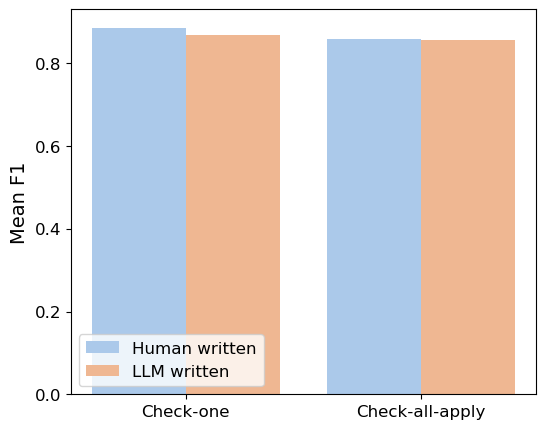

In [330]:
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (6, 5)
# yerr = results[['cil', 'cih']].to_numpy().reshape(2, 3,2)
ax=sns.barplot(data=new_file, x="Question type", y="Mean F1", 
            hue="Approach")
# plt.xticks(rotation=10)
# ax.errorbar(results['Approach'], results['Mean F1'], yerr=results['ci'], fmt='o', color='b', alpha=0.5)
# ax.fig.errorbar(data=results, x='Approach', y='Mean F1', yerr='ci', ls='', lw=3, color='black')
ax.set(xlabel=None)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[:], labels=labels[:])
sns.move_legend(ax, "lower left")
num_hues = 3

for (hue, df_hue), dogde_dist in zip(new_file.groupby('Approach', sort=False), np.linspace(-0.4, 0.4, 2 * num_hues + 1)[1::2]):
    bars = ax.errorbar(data=df_hue, x='Question type', y='Mean F1', ls='', lw=3, color='black')
    xys = bars.lines[0].get_xydata()
    bars.remove()
    # ax.errorbar(data=df_hue, x=xys[:, 0] + dogde_dist, y='Avg Kappa', yerr='ci', ls='', linewidth=2, capsize=6, color='#607c8e')


plt.show()
ax.figure.savefig("qt_results_f1.png")